In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers, Sequential
import matplotlib.pyplot as plt

In [2]:
IMG_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3

In [3]:
dataset = keras.utils.image_dataset_from_directory(
    'dataset',
    shuffle = True,
    image_size = (IMG_SIZE, IMG_SIZE),
    batch_size = BATCH_SIZE 
)

Found 2152 files belonging to 3 classes.


2026-04-01 18:42:36.683623: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-04-01 18:42:36.683937: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-01 18:42:36.683950: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-01 18:42:36.684232: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-01 18:42:36.684255: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [4]:
class_names  = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [5]:
print("Length of dataset: 2152/32 =",2152/32)

Length of dataset: 2152/32 = 67.25


In [6]:
len(dataset)

68

2026-04-01 18:45:46.114451: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


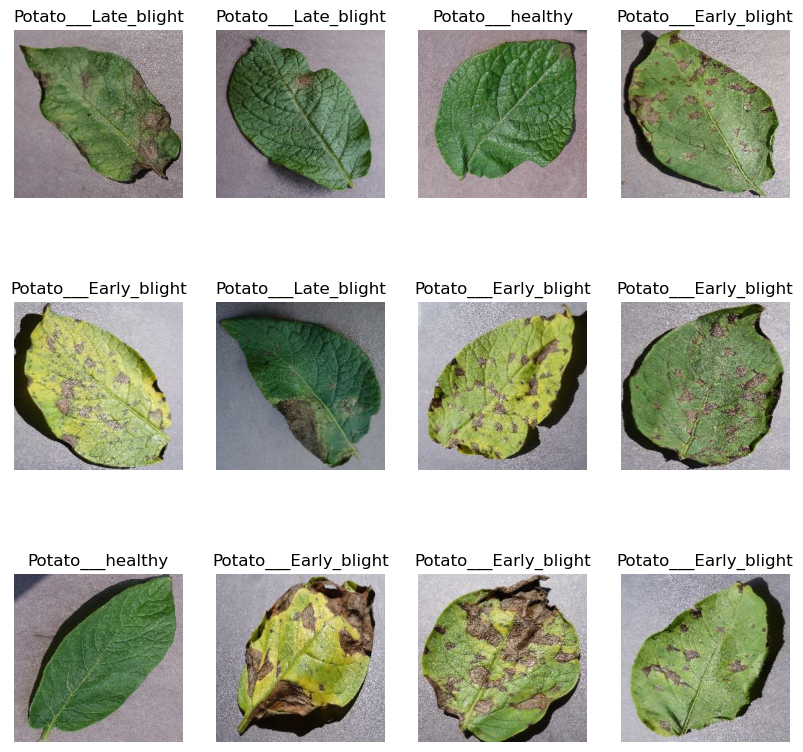

In [13]:
plt.figure(figsize=(10, 10))
for image_batch, label_batch in dataset.take(1):

    for i in range(12):
        # print(image_batch[0].numpy().shape)
        # print(label_batch[0].numpy()) #label of every image of this batch

        plt.subplot(3,4, i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")


In [14]:
len(dataset)

68

- 80% ==> training
- 20% ==> 10% validation, 10% test

In [16]:
train_size = 0.8

len(dataset)*0.8

54.400000000000006

In [17]:
train_ds = dataset.take(54)
len(train_ds)

54

In [18]:
test_ds = dataset.skip(54)
len(test_ds)

14

In [20]:
val_size = 0.1

len(dataset)*val_size

6.800000000000001

In [21]:
val_ds = test_ds.take(6)
test_ds = test_ds.skip(6)

In [25]:
# Now convert that into a function
def get_dataset_partition_tf(ds, train_split=0.8, test_split=0.1, val_split=0.1, shuffle=True, shuffle_size=10000):

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    ds_size = len(ds)

    train_size = int(train_split*ds_size)
    val_size = int(val_split*ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds


In [26]:
train_ds, val_ds, test_ds = get_dataset_partition_tf(dataset)

In [27]:
print(len(train_ds))
print(len(val_ds))
print(len(test_ds))

54
6
8


 - `.cache()` is used to store your dataset in memory (or disk) after the first iteration, so that future epochs are much faster.
 - `.prefetch()` lets your model prepare the next batch while the current batch is training.


In [28]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [31]:
resize_and_rescale = keras.Sequential([
    keras.layers.Resizing(IMG_SIZE, IMG_SIZE),
    keras.layers.Rescaling(1.0/255)
])

In [32]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
])